# Training and Fine-Tuning BERT for Classification
## Classfying Goodreads Reviews By Book Genre

This notebook will demonstrate how users can train and fine-tune a BERT model for classification with the popular HuggingFace `transformers` Python library.

We will fine-tune a BERT model on Goodreads reviews from the [UCSD Book Graph](https://mengtingwan.github.io/data/goodreads.html) with the goal of predicting the genre of the book being reviewed. The genres include:
- poetry
- comics & graphic
- fantasy & paranormal
- history & biography
- mystery, thriller, & crime
- romance
- young adult  

## **Import necessary Python libraries and modules**

First, we will import necessary Python libraries and modules. These include as `gdown`, for downloading large files from Google Drive (where we will get our UCSD Goodreads reviews), as well as scikit-learn (`sklearn`) and PyTorch (`torch`), for various machine learning tools.

In [1]:
!pip3 install -U transformers
!pip install --upgrade transformers

In [2]:
# Basic Python modules
from collections import defaultdict
import random
import pickle

# For downloading large files from Google Drive
# https://github.com/wkentaro/gdown
import gdown

# For working with gzip files
# https://docs.python.org/3/library/gzip.html
import gzip

# For working with JSON files
import json

# For data manipulation and analysis
import pandas as pd
import numpy as np

# For machine learning tools and evaluation
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

# For deep learning
# https://pytorch.org/tutorials/beginner/basics/quickstart_tutorial.html
import torch

# For plotting and data visualization
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker
sns.set(style='ticks', font_scale=1.2)

The HuggingFace [`transformers` Python library](https://huggingface.co/transformers/installation.html) is included in Colab by default now, so we do not need to install it (but this is how you would install it with `pip`).

From `transformers`, we will import modules for `DistilBert`, a *distilled* or smaller version of a BERT model that runs more quickly and uses less computing power. This makes it ideal for those just getting started with BERT.

In [3]:
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from transformers import Trainer, TrainingArguments

## **Set parameters and file paths**

In [4]:
# This is the name of the BERT model that we want to use.
model_name = 'distilbert-base-cased'

# This is the name of the program management system for NVIDIA GPUs. We're going to send our code here.
device_name = 'cuda'

# This is the maximum number of tokens in any document sent to BERT.
max_length = 512

# This is the name of the directory where we'll save our model. You can name it whatever you want.
cached_model_directory_name = 'distilbert-reviews-genres'

## **Initialising WANDB & HF Tokens**

In [5]:
# In your Kaggle Notebook — run this first
from kaggle_secrets import UserSecretsClient
 
secrets = UserSecretsClient()
WANDB_API_KEY = secrets.get_secret('WANDB_API_KEY')
HF_TOKEN  	= secrets.get_secret('HF_TOKEN')
 
import os
os.environ['WANDB_API_KEY'] = WANDB_API_KEY
os.environ['HF_TOKEN']      = HF_TOKEN
print ("key loaded")

key loaded


In this cell, we create a Python dictionary with each genre and the link to the corresponding UCSD Goodreads review data for that genre.

In [6]:
# This is where our target data is hosted on the web. You only need these paths for the book review dataset.

# Source: https://mengtingwan.github.io/data/goodreads.html#datasets

genre_url_dict = {'poetry':                 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_poetry.json.gz',
                  'children':               'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_children.json.gz',
                  'comics_graphic':         'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_comics_graphic.json.gz',
                  'fantasy_paranormal':     'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_fantasy_paranormal.json.gz',
                  'history_biography':      'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_history_biography.json.gz',
                  'mystery_thriller_crime': 'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_mystery_thriller_crime.json.gz',
                  'romance':                'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_romance.json.gz',
                  'young_adult':            'https://mcauleylab.ucsd.edu/public_datasets/gdrive/goodreads/byGenre/goodreads_reviews_young_adult.json.gz'}

In [7]:
# Now we will load the first 100,000 reviews from each link and randomly sample 2,000 reviews.

import requests
# Stream reviews from URL and collect a subset
def load_reviews(url, head=10000, sample_size=2000):
    reviews = []
    count = 0

    response = requests.get(url, stream=True)
    print(response)
    with gzip.open(response.raw, 'rt', encoding='utf-8') as file:
        for line in file:
            d = json.loads(line)
            reviews.append(d['review_text'])
            count += 1

            # Stop if we have reached the 100,000 limit
            if head is not None and count >= head:
                break

    # Return random sample of reviews
    return random.sample(reviews, min(sample_size, len(reviews)))

# Reviews by genre
genre_reviews_dict = {}

# Load reviews for each genre
for genre, url in genre_url_dict.items():
    print(f'Loading reviews for genre: {genre}')
    genre_reviews_dict[genre] = load_reviews(url, head=10000, sample_size=2000)


Loading reviews for genre: poetry
<Response [200]>
Loading reviews for genre: children
<Response [200]>
Loading reviews for genre: comics_graphic
<Response [200]>
Loading reviews for genre: fantasy_paranormal
<Response [200]>
Loading reviews for genre: history_biography
<Response [200]>
Loading reviews for genre: mystery_thriller_crime
<Response [200]>
Loading reviews for genre: romance
<Response [200]>
Loading reviews for genre: young_adult
<Response [200]>


In [8]:
# Let's preview a couple of the key-value pairs in `genre_reviews_dict`
for _genre, _reviews in genre_reviews_dict.items():
    print(_genre)
    print(random.sample(_reviews, 1)[0])

poetry
wlm 'kn 'Hsb 'n jyms jwys qd yktb sh`r, lkny fwjy't b'n lh sh`r, Gny'y `dhb, ykhtl Hb, wsbb `tqdy 'n nthrh S`b mnGlq, dhw trkyb Gryb@ ysmwnh trkyb (jwysy@) nsb@ lyh, wjwys yHtj lSbr w'nt tqr' nthrh, f(ns mn dbln) thqyl@ `ly lrwH, l ykml qrth l Sbwr w(`wlys) kdhlk, tSyb blhlws w'nt tqrw'h
children
Text: 3 stars 
 Illustrations: 4 stars 
 This book is mis-titled; it's less about animal sounds and more focused on their habitats. The last few pages relate the locations of each animal in more detail. I wish a map had also been included to show the animal locations in relation to one another, and to the reader's hometown. 
 I'm a huge fan of Melissa Sweet's art, but I'm not sure her collages are the best match for this particular book. A more realistic art style would have conveyed the habitats more effectively.
comics_graphic
I like how we learned a bit more about the keys and how Kinsey and Tyler now understand what's happening. That was fine. However, I don't like how this book fea

In [9]:
# Here we use `pickle` to save this Python dictionary to a `.pickle` file so we can easily load it later.
#The `pickle` module allows you to save and load Python objects like lists and dictionaries.

pickle.dump(genre_reviews_dict, open('genre_reviews_dict.pickle', 'wb'))


## **Split the data into training and test sets**

When training a machine learning model, it is necessary to split your training data into two parts: a "training" set and a "test" set.

We will train our BERT model on the "training" set of Goodreads reviews and then we will evaluate how well it is performing by running it on the "test" set of Goodreads reviews that the model has never seen before.

Normally, to tune the hyperparameters, you should also create a "validation" set for tuning, and only use the "test" set once, at the end of all tuning. For simplicity, in this tutorial, we will only using a training and test set.

In [10]:
train_texts = []
train_labels = []

test_texts = []
test_labels = []

for _genre, _reviews in genre_reviews_dict.items():

  _reviews = random.sample(_reviews, 1000) # Use a very small set as an example.

  for _review in _reviews[:800]:
    train_texts.append(_review)
    train_labels.append(_genre)
  for _review in _reviews[800:]:
    test_texts.append(_review)
    test_labels.append(_genre)

In [11]:
# Show how many Goodreads reviews and labels we have in each category: 6400 training reviews, 6400 training labels (genres), 1600 test reviews, 1600 test labels (genre)

len(train_texts), len(train_labels), len(test_texts), len(test_labels)

(6400, 6400, 1600, 1600)

In [12]:
# Here's an example of a training label and review:
train_labels[0], train_texts[0]

('poetry',
 'Tosa khronia (apo otan to eikha diabasei sta Klassika Eikonographemena) nomiza oti etan ena indianiko epos. Tora suneidetopoio oti to egrapse enas leukos; Mou khalase ole ten apolause, ole ten epistrophe sten paidike elikia.')

<br><br>

## **Run a baseline model (logistic regression)**

Here we train and evaluate a simple TF-IDF baseline model using logistic regression.

We find better-than-random performance, even for a very small dataset. We'll see whether BERT can beat this good baseline!

In [13]:
vectorizer = TfidfVectorizer()
X_train = vectorizer.fit_transform(train_texts)
X_test = vectorizer.transform(test_texts)

In [14]:
# We train a logistic regression model from scikit-learn on the Goodreads training data, 
# and then we use the trained model to make predictions on our Goodreads review test set.
model = LogisticRegression(max_iter=1000).fit(X_train, train_labels)
predictions = model.predict(X_test)

We can use scikit-learn's `classification_report` function to evaluate how well the logistic regression model's predictions match up with the true labels for the Goodreads reviews.

Importantly, we can see that our average scores are above random performance (we have 8 classes, so random performance would be ~0.2).

In [15]:
print(classification_report(test_labels, predictions))

                        precision    recall  f1-score   support

              children       0.60      0.63      0.62       200
        comics_graphic       0.77      0.70      0.73       200
    fantasy_paranormal       0.34      0.25      0.29       200
     history_biography       0.52      0.48      0.50       200
mystery_thriller_crime       0.55      0.50      0.52       200
                poetry       0.61      0.73      0.67       200
               romance       0.52      0.64      0.57       200
           young_adult       0.38      0.40      0.39       200

              accuracy                           0.54      1600
             macro avg       0.54      0.54      0.54      1600
          weighted avg       0.54      0.54      0.54      1600



## **Encode data for BERT**

We're going to transform our texts and labels into a format that BERT (via Huggingface and PyTorch) will understand. This is called *encoding* the data.

Here are the steps we need to follow:

1. The labels&mdash;in this case, Goodreads genres&mdash;need to be turned into integers rather than strings.

2. The texts&mdash;in this case, Goodreads reviews&mdash;need to be truncated if they're more than 512 tokens or padded if they're fewer than 512 tokens. The tokens, or words in the texts, also need to be separated into "word pieces" and matched to their embedding vectors.

3. We need to add special tokens to help BERT:

| BERT special token | Explanation |
| --------------| ---------|
| [CLS] | Start token of every document. |
| [SEP] | Separator between each sentence |
| [PAD] | Padding at the end of the document as many times as necessary, up to 512 tokens |
|  &#35;&#35; | Start of a "word piece" |




Here we will load `DistilBertTokenizerFast` from the HuggingFace library, which will do all the work of encoding the texts for us. The `tokenizer()` will break word tokens into word pieces, truncate to 512 tokens, and add padding and special BERT tokens.

In [16]:
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name) # The model_name needs to match our pre-trained model.

Here we will create a map of our labels, or Goodreads genres, to integer keys. We take the unique labels, and then we make a dictionary that associates each label/tag with an integer.

**Note:** HuggingFace documentation sometimes refers to "labels" as "tags" but these are the same thing. We use "labels" throughout this notebook for clarity.

In [17]:
unique_labels = set(label for label in train_labels)
label2id = {label: id for id, label in enumerate(unique_labels)}
id2label = {id: label for label, id in label2id.items()}

In [18]:
label2id.keys()

dict_keys(['comics_graphic', 'history_biography', 'mystery_thriller_crime', 'fantasy_paranormal', 'children', 'young_adult', 'poetry', 'romance'])

In [19]:
id2label.keys()

dict_keys([0, 1, 2, 3, 4, 5, 6, 7])

In [20]:
#Now let's encode our texts and labels!

train_encodings = tokenizer(train_texts, truncation=True, padding=True, max_length=max_length)
test_encodings  = tokenizer(test_texts, truncation=True, padding=True, max_length=max_length)

train_labels_encoded = [label2id[y] for y in train_labels]
test_labels_encoded  = [label2id[y] for y in test_labels]

**Examine a Goodreads review in the training set after encoding**

In [21]:
' '.join(train_encodings[0].tokens[0:100])

'[CLS] To ##sa k ##hr ##onia ( a ##po o ##tan to e ##ik ##ha di ##aba ##sei s ##ta K ##lass ##ika E ##iko ##no ##graph ##em ##ena ) no ##mi ##za o ##ti et ##an en ##a in ##dian ##iko e ##po ##s . Tor ##a sun ##ei ##det ##op ##oi ##o o ##ti to e ##gra ##pse en ##as le ##uk ##os ; Mo ##u k ##hala ##se o ##le ten a ##pol ##aus ##e , o ##le ten e ##pis ##tro ##phe s ##ten paid ##ike el ##iki ##a . [SEP] [PAD] [PAD] [PAD] [PAD] [PAD]'

**Examine a Goodreads review in the test set after encoding**

In [22]:
' '.join(test_encodings[0].tokens[0:100])

'[CLS] 2nd read began April 7 , 2011 [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]'

**Examine the training labels after encoding**

In [23]:
set(train_labels_encoded)

{0, 1, 2, 3, 4, 5, 6, 7}

**Examine the test labels after encoding**

In [24]:
set(test_labels_encoded)

{0, 1, 2, 3, 4, 5, 6, 7}

## **Make a custom Torch dataset**

Here we combine the encoded labels and texts into dataset objects. We use the custom Torch `MyDataSet` class to make a `train_dataset` object from  the `train_encodings` and `train_labels_encoded`. We also make a `test_dataset` object from `test_encodings`, and `test_labels_encoded`.

In [25]:
class MyDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [26]:
train_dataset = MyDataset(train_encodings, train_labels_encoded)
test_dataset = MyDataset(test_encodings, test_labels_encoded)

**Examine a Goodreads review in the Torch `training_dataset` after encoding**

In [27]:
' '.join(train_dataset.encodings[0].tokens[0:100])

'[CLS] To ##sa k ##hr ##onia ( a ##po o ##tan to e ##ik ##ha di ##aba ##sei s ##ta K ##lass ##ika E ##iko ##no ##graph ##em ##ena ) no ##mi ##za o ##ti et ##an en ##a in ##dian ##iko e ##po ##s . Tor ##a sun ##ei ##det ##op ##oi ##o o ##ti to e ##gra ##pse en ##as le ##uk ##os ; Mo ##u k ##hala ##se o ##le ten a ##pol ##aus ##e , o ##le ten e ##pis ##tro ##phe s ##ten paid ##ike el ##iki ##a . [SEP] [PAD] [PAD] [PAD] [PAD] [PAD]'

**Examine a Goodreads review in the Torch `test_dataset` after encoding**

In [28]:
' '.join(test_dataset.encodings[1].tokens[0:100])

"[CLS] I ' m am ##bi ##valent about a lot of the poems in the last 3rd of the book but overall I really enjoyed this ( as a poetry collection w / a narrative arc and as a historical narrative ) . [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]"

## **Load pre-trained BERT model**

Here we load a pre-trained DistilBERT model and send it to CUDA.

**Note:** If you decide to repeat fine-tuning after already running the following cells, make sure that you re-run this cell to re-load the original pre-trained model before fine-tuning again.

In [29]:
# The model_name needs to match the name used for the tokenizer above.
model = DistilBertForSequenceClassification.from_pretrained(model_name, num_labels=len(id2label)).to(device_name)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-cased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## **Set the BERT fine-tuning parameters**

These are the arguments we'll set in the HuggingFace TrainingArguments objects, which we'll then pass to the HuggingFace Trainer object. There are many more possible arguments, but here we highlight the basics and some common gotchas.

When training your own model, you should search over these parameters to find the best settings for your particular dataset. You should use a held-out set of validation data for this step.

| Parameter | Explanation |
|-----------| ------------|
| num_train_epochs | total number of training epochs (how many times to pass through the entire dataset; too much can cause overfitting) |
| per_device_train_batch_size | batch size per device during training |
| per_device_eval_batch_size |  batch size for evaluation |
|  warmup_steps |  number of warmup steps for learning rate scheduler (set lower because of small dataset size) |
| weight_decay | strength of weight decay (reduces size of weights, like regularization) |
| output_dir | output directory for the fine-tuned model and configuration files |
| logging_dir | directory for storing logs |
| logging_steps | how often to print logging output (so that we can stop training early if the loss isn't going down) |
| evaluation_strategy | evaluate while training so that we can see the accuracy going up |

In [30]:
training_args = TrainingArguments(
    num_train_epochs=3,              # total number of training epochs
    per_device_train_batch_size=10,  # batch size per device during training
    per_device_eval_batch_size=16,   # batch size for evaluation
    learning_rate=5e-5,              # initial learning rate for Adam optimizer
    warmup_steps=100,                # number of warmup steps for learning rate scheduler (set lower because of small dataset size)
    weight_decay=0.01,               # strength of weight decay
    output_dir='./results',          # output directory
    logging_dir='./logs',            # directory for storing logs
    logging_steps=100,               # number of steps to output logging (set lower because of small dataset size)
    eval_strategy='steps',     # evaluate during fine-tuning so that we can see progress
    report_to='wandb',  # Disables wandb logging
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


## **Fine-tune the BERT model**

First, lets define a custom evaluation function that returns the accuracy. You could modify this function to return precision, recall, F1, and/or other metrics.

In [31]:
def compute_metrics(pred):
  labels = pred.label_ids
  preds = pred.predictions.argmax(-1)
  acc = accuracy_score(labels, preds)
  return {
      'accuracy': acc,
  }

Then we create a HuggingFace `Trainer` object using the `TrainingArguments` object that we created above. We also send our `compute_metrics` function to the `Trainer` object, along with our test and train datasets.

**Note:** This is what we've been aiming for this whole time! All the work of tokenizing, creating datasets, and setting the training arguments was for this cell.

In [32]:
trainer = Trainer(
    model=model,                         # the instantiated Transformers model to be trained
    args=training_args,                  # training arguments, defined above
    train_dataset=train_dataset,         # training dataset
    eval_dataset=test_dataset,           # evaluation dataset (usually a validation set; here we just send our test set)
    compute_metrics=compute_metrics      # our custom evaluation function
)

Time to finally fine-tune!

Be patient; if you've set everything in Colab to use GPUs, then it should only take a minute or two to run, but if you're running on CPU, it can take hours.

After every 10 steps (as we specified in the TrainingArguments object), the trainer will output the current state of the model, including the training loss, validation ("test") loss, and accuracy (from our `compute_metrics` function).

You should see the loss going down and the accuracy going up. If instead they are staying the same or oscillating, you probably need to change the fine-tuning parameters.

In [33]:
# Turn off weights and biases logging, which requires an API key

import os
os.environ["WANDB_DISABLED"] = "true"

In [34]:
trainer.train()

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: g25ait2077 (vivek-iitj) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Step,Training Loss,Validation Loss,Accuracy
100,3.910656,3.249297,0.419375
200,2.870476,2.595679,0.544375
300,2.574106,2.488194,0.551250
400,2.231349,2.470333,0.559375
500,1.874393,2.391171,0.576875
600,2.018181,2.283985,0.593750
700,1.605619,2.350873,0.589375
800,1.327596,2.324002,0.598125
900,1.290935,2.330680,0.600625
960,1.290935,2.318858,0.598750


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=960, training_loss=2.134795411427816, metrics={'train_runtime': 704.3568, 'train_samples_per_second': 27.259, 'train_steps_per_second': 1.363, 'total_flos': 2543646198988800.0, 'train_loss': 2.134795411427816, 'epoch': 3.0})

## **Save fine-tuned model**

The following cell will save the model and its configuration files to a directory in Colab. To preserve this model for future use, you should download the model to your computer.

In [35]:
trainer.save_model(cached_model_directory_name)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

## **Evaluate fine-tuned model**

The following function of the `Trainer` object will run the built-in evaluation, including our `compute_metrics` function.

In [37]:
trainer.evaluate()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Training Loss,Validation Loss,Step,Accuracy
1.290935,2.318858,960,0.598750


{'eval_loss': 2.3188581466674805, 'eval_accuracy': 0.59875}

In [38]:
# But we might want to do more fine-grained analysis of the model, so we extract the predicted labels.
predicted_results = trainer.predict(test_dataset)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


In [39]:
predicted_results.predictions.shape

(1600, 8)

In [40]:
predicted_labels = predicted_results.predictions.argmax(-1) # Get the highest probability prediction
predicted_labels = predicted_labels.flatten().tolist()      # Flatten the predictions into a 1D list
predicted_labels = [id2label[l] for l in predicted_labels]  # Convert from integers back to strings for readability

In [41]:
len(predicted_labels)

1600

In [42]:
print(classification_report(test_labels,
                            predicted_labels))

                        precision    recall  f1-score   support

              children       0.64      0.69      0.67       200
        comics_graphic       0.82      0.74      0.78       200
    fantasy_paranormal       0.41      0.48      0.44       200
     history_biography       0.59      0.59      0.59       200
mystery_thriller_crime       0.57      0.59      0.58       200
                poetry       0.76      0.73      0.75       200
               romance       0.68      0.58      0.63       200
           young_adult       0.38      0.36      0.37       200

              accuracy                           0.60      1600
             macro avg       0.61      0.60      0.60      1600
          weighted avg       0.61      0.60      0.60      1600



<br><br>

## **Pull out correct and incorrect classifications for examination**

Let's use our predicted labels for some analysis!

Now that we've fine-tuned and pulled out our predicted labels, the BERT part of this tutorial is done. You can now use the predicted labels in the same way you would use any set of predicted labels from any classification model. We'll show some examples here.

First, let's print out some example predictions that were correct.

In [43]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 20):
  if _true_label == _predicted_label:
    print('LABEL:', _true_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

LABEL: romance
REVIEW TEXT: Oh, for the love of football...and hot football playas! 
 What can I say about Simone Elkeles? She i ...

LABEL: poetry
REVIEW TEXT: Exquisite, lyrical, exquisite, exquisite, exquisite. ...

LABEL: young_adult
REVIEW TEXT: See full review for The Princess Diaries at: https://toomanybooksnotenoughshelves.... 
 To be clear  ...

LABEL: comics_graphic
REVIEW TEXT: In many ways, this is a bog standard Hellblazer story: demon slips free from ancient bonds, tries to ...

LABEL: comics_graphic
REVIEW TEXT: French sci-fi BD from the 1970s - a classic of the genre. ...

LABEL: children
REVIEW TEXT: Children's picture book by a Danish author that features Death chatting with 4 children as he prepar ...

LABEL: children
REVIEW TEXT: This compilation of short stories and myths based on the Celtic culture was fantastic! The illustrat ...

LABEL: romance
REVIEW TEXT: LOVED THIS BOOK SO HARD!!! IT IS TOTALLY AMAZING!!! And the narration is INCREDIBLE!!! 
 One of the  ...



Now let's print out some misclassifications.

In [44]:
for _true_label, _predicted_label, _text in random.sample(list(zip(test_labels, predicted_labels, test_texts)), 20):
  if _true_label != _predicted_label:
    print('TRUE LABEL:', _true_label)
    print('PREDICTED LABEL:', _predicted_label)
    print('REVIEW TEXT:', _text[:100], '...')
    print()

TRUE LABEL: comics_graphic
PREDICTED LABEL: history_biography
REVIEW TEXT: It really surprised me but I really liked it back when I read it, although it wasn't super impressiv ...

TRUE LABEL: mystery_thriller_crime
PREDICTED LABEL: young_adult
REVIEW TEXT: 2.5 stars. Turn off your common sense, logic and all grounding sense of believability when reading t ...

TRUE LABEL: romance
PREDICTED LABEL: fantasy_paranormal
REVIEW TEXT: Awesome writer! 
 Great story with strong leading characters. I loved the alpha on both parts. This  ...

TRUE LABEL: young_adult
PREDICTED LABEL: fantasy_paranormal
REVIEW TEXT: I'm just going to say that I'm glad I read this. Dragons are one of the oldest staples of fantasy, b ...

TRUE LABEL: history_biography
PREDICTED LABEL: fantasy_paranormal
REVIEW TEXT: Morrisonin kirjat ovat aina koskettavia ja jollain tavalla erityisia, eika tama kirja tee poikkeusta ...

TRUE LABEL: young_adult
PREDICTED LABEL: fantasy_paranormal
REVIEW TEXT: Light quick read. Enough

Finally, let's create some heatmaps to examine misclassification patterns. We could use these patterns to think about similarities and differences between genres, according to book reviewers.

In [45]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

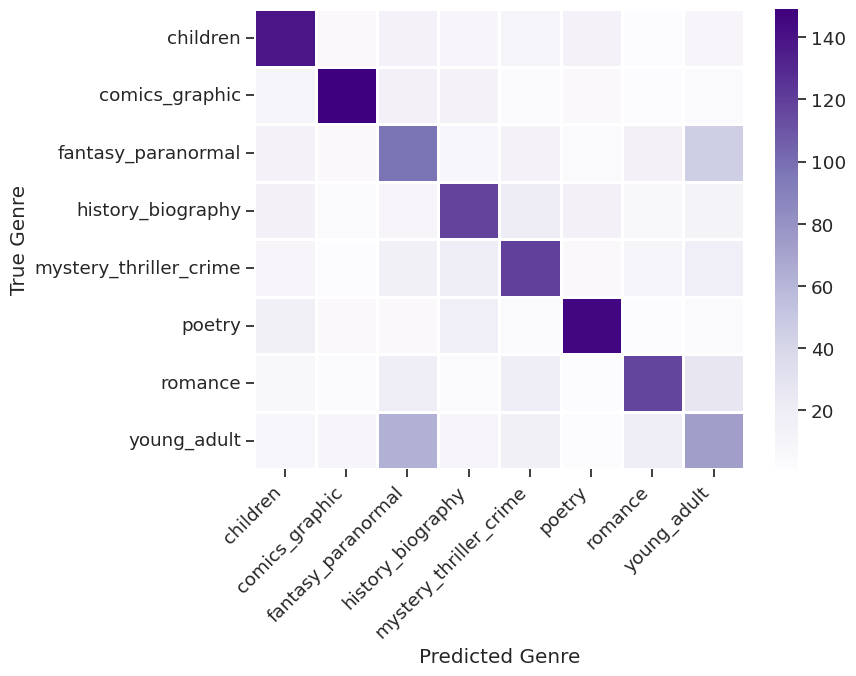

In [46]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Looks good! We can see that overall, our model is assigning the correct labels for each genre.

Now, let's remove the diagonal from the plot to highlight the misclassifications.

In [47]:
genre_classifications_dict = defaultdict(int)
for _true_label, _predicted_label in zip(test_labels, predicted_labels):
  if _true_label != _predicted_label: # Remove the diagonal to highlight misclassifications
    genre_classifications_dict[(_true_label, _predicted_label)] += 1

dicts_to_plot = []
for (_true_genre, _predicted_genre), _count in genre_classifications_dict.items():
  dicts_to_plot.append({'True Genre': _true_genre,
                        'Predicted Genre': _predicted_genre,
                        'Number of Classifications': _count})

df_to_plot = pd.DataFrame(dicts_to_plot)
df_wide = df_to_plot.pivot_table(index='True Genre',
                                 columns='Predicted Genre',
                                 values='Number of Classifications')

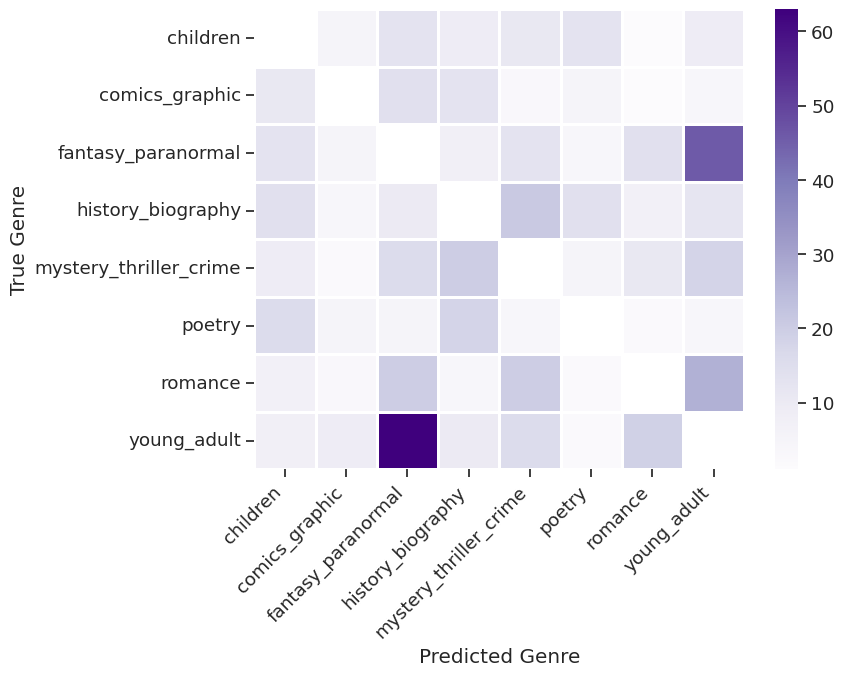

In [48]:
plt.figure(figsize=(9,7))
sns.set(style='ticks', font_scale=1.2)
sns.heatmap(df_wide, linewidths=1, cmap='Purples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

There's much more you can do with your own dataset and labels! Classification can be used to apply a small set of labels across a big dataset; to explore misclassifications to better understand users; and much more! We hope you'll use this tutorial in all kinds of creative ways.

I chose the **DistilBERT-base-cased** model because it offers an excellent balance between accuracy and efficiency. According to its Hugging Face model card, DistilBERT is a distilled version of BERT that reduces the number of parameters by 40% while retaining about 97% of BERT’s performance on language understanding benchmarks. 

This makes it faster and lighter, which is ideal for projects where computational resources are limited or where real-time inference is required. Despite being smaller, DistilBERT still captures rich contextual information from text, making it suitable for tasks such as sentiment analysis, classification, and question answering. 

I've selected this model because it provides strong results with lower memory and processing requirements, making it practical for both academic experiments and deployment in production environments.

In [49]:
import wandb
from transformers import TrainingArguments, Trainer
from sklearn.metrics import accuracy_score, f1_score
 
# 1. Initialise W&B
wandb.init(
    project="mlops-assignment2",
    name="distilbert-run-mlops-asgn2",
	config={
    	"model": model_name,
        "epochs": 3,
        "batch_size": 16,
        "learning_rate": 3e-5,
        "max_length": max_length,
        "dataset": "UCSD Goodreads",
        "platform": "Kaggle",
	}
)

# Print the model's max allowed token ID (should be 30521)
print("Max allowed ID:", model.config.vocab_size - 1)

# Check your actual input data batch
#max_input_id = inputs['input_ids'].max().item()
#print("Your max input ID:", max_input_id)

#if max_input_id >= model.config.vocab_size:
#    print("❌ ERROR: Your data contains token IDs too large for DistilBERT!")

eval/accuracy,▁▆▆▆▇██████
eval/loss,█▃▂▂▂▁▁▁▁▁▁
eval/runtime,█▂▁▂▂▂▁▂▂▂▅
eval/samples_per_second,▁▇█▇▇▇█▇▇▇▄
eval/steps_per_second,▁▇█▇▇▇█▇▇▇▄
test/accuracy,▁
test/loss,▁
test/runtime,▁
test/samples_per_second,▁
test/steps_per_second,▁
+5,...


Max allowed ID: 28995


In [50]:
# 2. Define evaluation metrics
def compute_metrics(pred):
	labels = pred.label_ids
	preds  = pred.predictions.argmax(-1)
	return {
        "accuracy": accuracy_score(labels, preds),
        "f1":       f1_score(labels, preds, average="weighted")
	}

In [51]:
# 3. Training arguments
training_args = TrainingArguments(
    output_dir="./results",
	num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
	warmup_steps=100,
	weight_decay=0.01,
	logging_steps=50,
    eval_strategy="epoch",
	save_strategy="epoch",
    load_best_model_at_end=True,
    report_to="wandb",
    run_name="distilbert-run-mlops-asgn2",
)

In [52]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

In [53]:
# 4. Train
trainer = Trainer(
	model=model,
	args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
)
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.097649,2.627493,0.596875,0.597899
2,0.839123,2.879751,0.583750,0.591138
3,0.493705,2.971332,0.593750,0.596675


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=600, training_loss=0.8145673688252767, metrics={'train_runtime': 577.1001, 'train_samples_per_second': 33.27, 'train_steps_per_second': 1.04, 'total_flos': 2543646198988800.0, 'train_loss': 0.8145673688252767, 'epoch': 3.0})

In [54]:
 
# 5. End W&B run
wandb.finish()


eval/accuracy,█▁▆
eval/f1,█▁▇
eval/loss,▁▆█
eval/runtime,█▅▁
eval/samples_per_second,▁▄█
eval/steps_per_second,▁▄█
train/epoch,▁▂▂▃▃▄▄▅▅▅▆▇▇███
train/global_step,▁▂▂▃▃▄▄▅▅▅▆▇▇███
train/grad_norm,▄▇█▅▄▅▆▅▁▄▄▄
train/learning_rate,▄█▇▇▆▅▅▄▃▂▂▁
+1,...


In [55]:
import json, wandb
from sklearn.metrics import classification_report
wandb.init()

# Run evaluation
eval_results = trainer.evaluate()
print(eval_results)
 
# Log final metrics to W&B
wandb.log({
    "final/loss":     eval_results["eval_loss"],
    "final/accuracy": eval_results["eval_accuracy"],
    "final/f1":       eval_results["eval_f1"],
})
 
# Save full classification report
preds  = trainer.predict(test_dataset).predictions.argmax(-1)
labels = [item["labels"].item() for item in test_dataset]
report = classification_report(
	labels, preds, target_names=list(id2label.values()), output_dict=True
)
 
with open("eval_report.json", "w") as f:
	json.dump(report, f, indent=2)
 
# Upload to W&B as a versioned Artifact
artifact = wandb.Artifact("eval-report", type="evaluation")
artifact.add_file("eval_report.json")
wandb.log_artifact(artifact)
#wandb.finish()


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Training Loss,Validation Loss,Epoch,Accuracy,F1
0.493705,2.627493,3,0.596875,0.597899


{'eval_loss': 2.627492904663086, 'eval_accuracy': 0.596875, 'eval_f1': 0.5978988479984099}


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


<Artifact eval-report>

In [56]:
from huggingface_hub import login
 
# HF_TOKEN was already loaded from Kaggle Secrets (see Task 4)
login(token=HF_TOKEN)
 
# Push model and tokenizer
model.push_to_hub("Vivek-ML-Projects/distilbert-goodreads-genres")
tokenizer.push_to_hub("Vivek-ML-Projects/distilbert-goodreads-genres")
 
# Record the link in W&B
wandb.run.summary["huggingface_model"] = \
    "https://huggingface.co/Vivek-ML-Projects/distilbert-goodreads-genres"


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.


In [57]:
wandb.finish()

eval/accuracy,▁
eval/f1,▁
eval/loss,▁
eval/runtime,▁
eval/samples_per_second,▁
eval/steps_per_second,▁
final/accuracy,▁
final/f1,▁
final/loss,▁
test/accuracy,▁
+7,...
